In this notebook, Unscented Kalman filter is introduced to the Kitti dataset. In Extended Kalman filter, the motion model is linearized using first-order Taylor expansion to approximate the nonlinear function about mean value of the random variable. However, uncertainty of the distribution, covariance, is not accurately reflect the actual distribution resulting in introducing large error in the true posterior mean and covariance of the transformed gaussian random variable.

Unlike KEF, the state distribution is approximated by a gaussian random variable represented by a minimal set of carefully chosen sample points (deterministic sampling approach).


In [1]:
import numpy as np
import pandas as pd
import sys
from sklearn.metrics import mean_squared_error
sys.path.append('/app/src')
from data_loader import DataLoader
from configs import MeasurementDataEnum, SetupEnum, ErrorEnum, Configs, NoiseTypeEnum, FilterEnum
from kalman_filters import UnscentedKalmanFilter

%matplotlib inline
np.random.seed(777)

- [Unscented Kalman filter description](#Unscented-Kalman-filter)
- [Load data](#Load-raw-data-0033)
- [Data visualization](#Display-data-with-noise)
- [Applying Unscented Kalman filter](#Applying-Unscented-Kalman-filter)
    - [Setup1](#Setup1-(IMU-input-->-UKF-with-Visual-Odometry-measurement))
        - [Setup1 result](#Setup1-Result)
    - [Setup2](#Setup2-(IMU-input-->-UKF-with-Visual-Odometry-and-GPS-measurement))
        - [Setup2 result](#Setup2-Result)
    - [Setup3](#Setup3-(INS-input-->-UKF-with-Visual-Odometry-and-INS-measurement))
        - [Setup3 result](#Setup3-Result)
- [Result](#Result)

## Unscented Kalman filter

Unscented Kalman filter approximate nonlinear motion model by using unscented transform instead of analytical transform that EKF performs. The unscented transformation is a method for calculating the mean and covariance of a random variable by passing it through a nonlinear function.

Like other filtering technique, Unscented Kalman filter follows the time update and measurement update steps.

In the time update step:

Suppose we have a random variable $x^{L}$, we compute a subset of points, called as sigma point, $\chi_{(i)}$, where i = 1...2L+1. Then a sigma vector $\chi$ is formed as follows:

$$\begin{align}
 \chi_{k-1}^{(i)} &= \hat{x_{k-1}} \\
 \chi_{k-1}^{(i)} &= \hat{x_{k-1}} + (\sqrt{(L+\lambda)*P_{x}})_{i}, i=1, ..., L\\
 \chi_{k-1}^{(i)} &= \hat{x_{k-1}} - (\sqrt{(L+\lambda)*P_{x}})_{i}, i=L+1, ..., 2L\\
\end{align}
$$
where, $\lambda$ is a caling parameter $\lambda = \alpha^{2}(L+k) - L$. $\alpha$ determins the spread of the sigma points around the sample mean $\hat{x}$, which is normally small positive value such as 0.001. Moreover, k is secondary scaling parameter, which is usually set to 0.

The number of sigma points required to approximate the nonlinearly transformed distribution is $2L + 1$. So, sigma points are chosen one point for the mean, and pair of points for the symetrically distributed about the mean.

Next, these sigma points are propagated through the nonlinear function:
$$\begin{align}
 \chi_{k-1}^{(i)} &= g(\chi_{k-1}^{(i)}, w_{k-1}, 0)
\end{align}
$$.

After propagation of all sigma points, sample mean and sample covariance of the propagated points are computed as follows:
$$\begin{align}
 \hat{x_{k}^{-}} &= \sum_{i=0}^{2L} W^{m}_{i}*\chi_{k-1}^{(i)}\\
 \hat{P_{x,k}} &= \sum_{i=0}^{2L} W^{c}_{i}*(\chi_{k-1}^{(i)} - \hat{x_{k}^{-}})(\chi_{k-1}^{(i)} - \hat{x_{k}^{-}})^{T} + Q_{k-1}
\end{align}
$$
where, Q is additive process noise.

In the measurement update step:

Once we obtain sample mean and covariance of propagated points, we predict measurement from the propagated sigma points.
$$\begin{align}
 z^{(i)}_{k, approx} &= h(\chi_{k-1}^{(i)}, w_{k-1}, 0)
\end{align}
$$

Finally, the approximated mean and covariance from the predicted measurements:
$$\begin{align}
 y_{k} &= \sum_{i=0}^{2L} W^{m}_{i}*z^{(i)}_{k, approx}\\
 \hat{P_{y,k}} &= \sum_{i=0}^{2L} W^{c}_{i}*(z^{(i)}_{k, approx} - y_{k})(z^{(i)}_{k, approx} - y_{k})^{T} + R_{k}
\end{align}
$$.

Besides the estimation, cross-covariance between propagated distribution and distribution of predicted measurement is computed as follows:
$$\begin{align}
 \hat{P_{xy,k}} &= \sum_{i=0}^{2L} W^{c}_{i}*(\chi_{k-1}^{(i)} - \hat{x_{k}^{-}})(z^{(i)}_{k, approx} - y^{(i)}_{k})^{T}
\end{align}
$$

Finally, Kalman gain and correction of the mean and covariance are performed as follows:
$$\begin{align}
 K_{k} &= \hat{P_{xy,k}} * \hat{P_{y,k}^{-1}}\\
 \hat{x_{k}} &= \hat{x_{k}^{-}} + K_{k}*(z_{k, actual} - y_{k})\\
 P_{k} &= \hat{P_{x,k}} - K_{k}*\hat{P_{y,k}}*K_{k}^{T}
\end{align}
$$
where $z_{k, actual}$ is sensor reading in measurement update step.


## Load raw data 0033

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


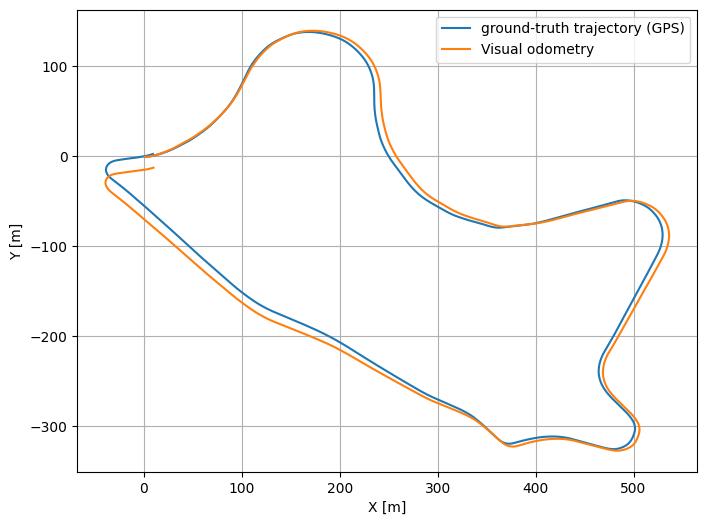

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path(root_path, 'data')
noise_vector_dir = os.path(root_path, 'exports/_noise_optimizations/noise_vectors')
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

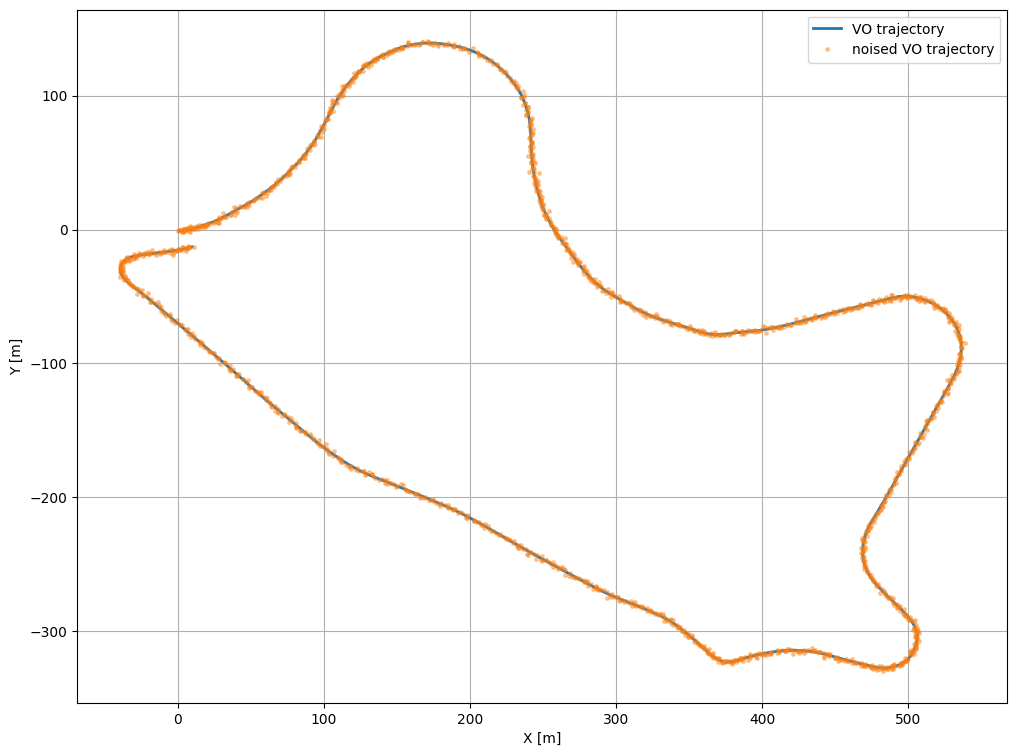

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

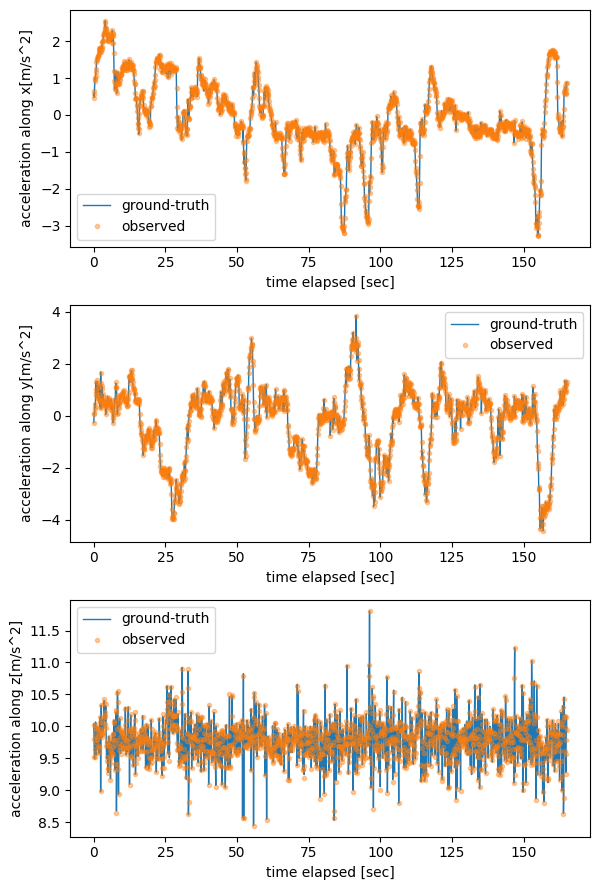

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

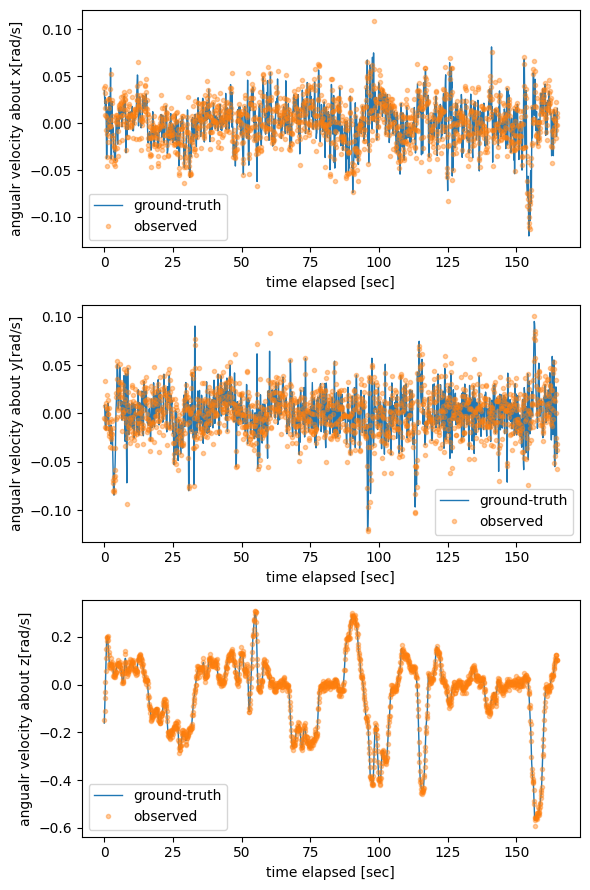

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

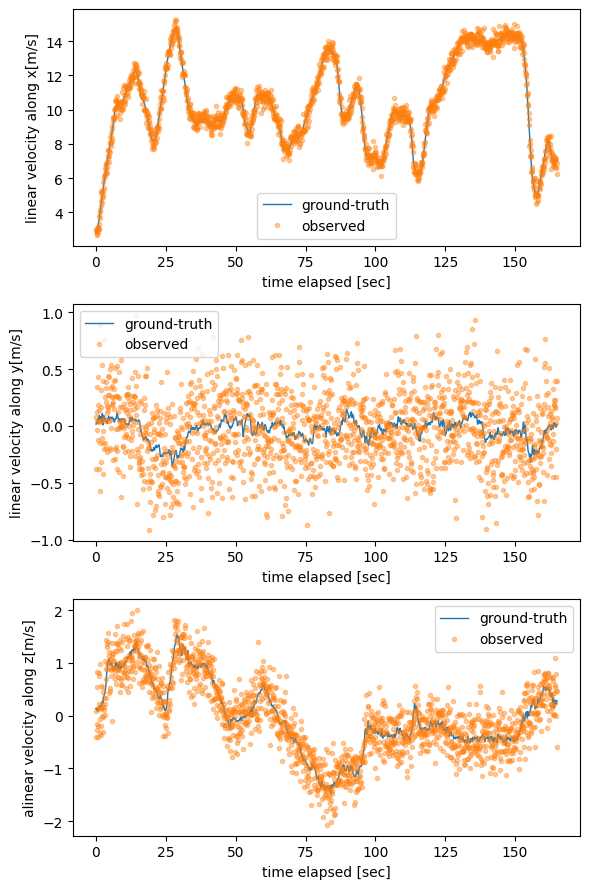

In [6]:
data.show_linear_velocity_with_noise()

# Applying Unscented Kalman filter

In [7]:
mae_errors = []
rmse_errors = []
max_errors = []

mae_vo = np.absolute(np.subtract(data.GPS_measurements_in_meter.T[:2, :], 
                                 data.VO_measurements.T[:2, :]))
rmse_vo = np.sqrt(mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], 
                                      data.VO_measurements.T[:2, :]))
max_vo = np.max(mae_vo)

print(f"MAE: {np.mean(mae_vo)}")
print(f"RMSE: {rmse_vo}")
print(f"MAX: {max_vo}")
mae_errors.append(np.round(np.mean(mae_vo), Configs.decimal_place))
rmse_errors.append(np.round(rmse_vo, Configs.decimal_place))
max_errors.append(np.round(max_vo, Configs.decimal_place))

MAE: 3.8204236798597773
RMSE: 5.448548458980544
MAX: 15.244254650508374


--------------

## Setup1 (IMU input -> EKF with Visual Odometry measurement)

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.UKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2476.87it/s]


----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.17 m
Root Mean Squared Error: 5.682 m
Maximum Error: 16.566 m
---------------------------------------------------



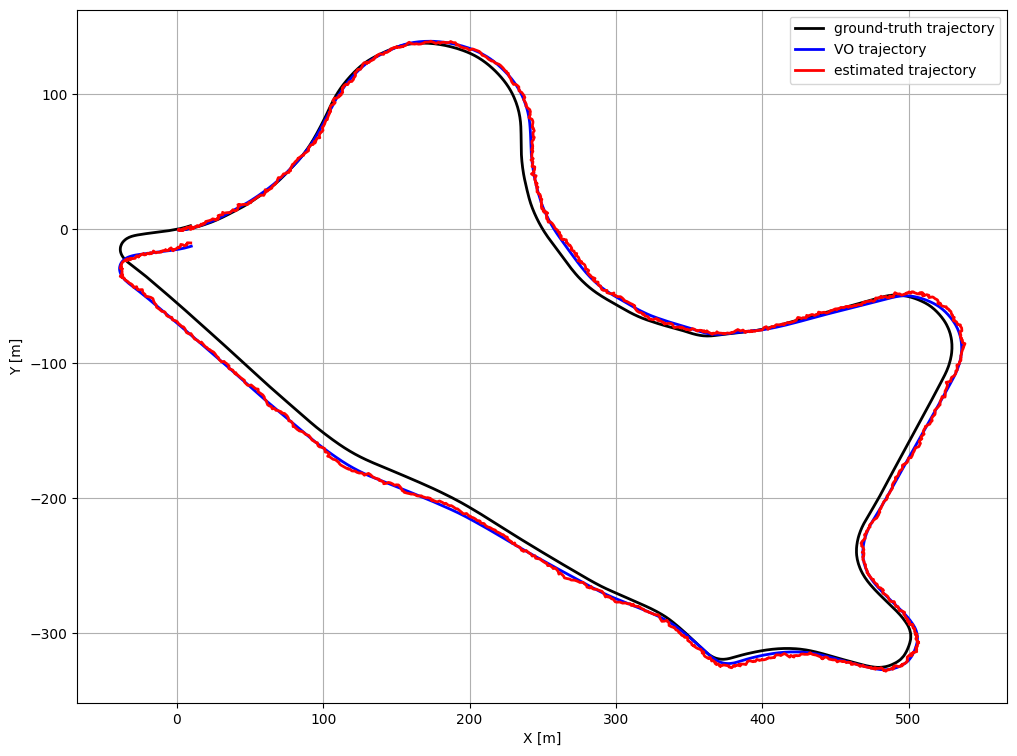

In [9]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

ukf1_0 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1
)
error_ukf1_0 = ukf1_0.run(
    data=data,
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

## Setup1 Result

In [10]:
print(f"MAE: {error_ukf1_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ukf1_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ukf1_0[ErrorEnum.MAX]}")

mae_errors.append(error_ukf1_0[ErrorEnum.MAE])
rmse_errors.append(error_ukf1_0[ErrorEnum.RMSE])
max_errors.append(error_ukf1_0[ErrorEnum.MAX])

MAE: 4.17
RMSE: 5.682
MAX: 16.566


## Setup2 (IMU input -> UKF with Visual Odometry and GPS measurement)

In [11]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=SetupEnum.SETUP_2, 
  filter_type=FilterEnum.UKF, 
  noise_type=NoiseTypeEnum.CURRENT
)

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2109.97it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.949 m
Root Mean Squared Error: 2.422 m
Maximum Error: 7.845 m
-------------------------------------------------------



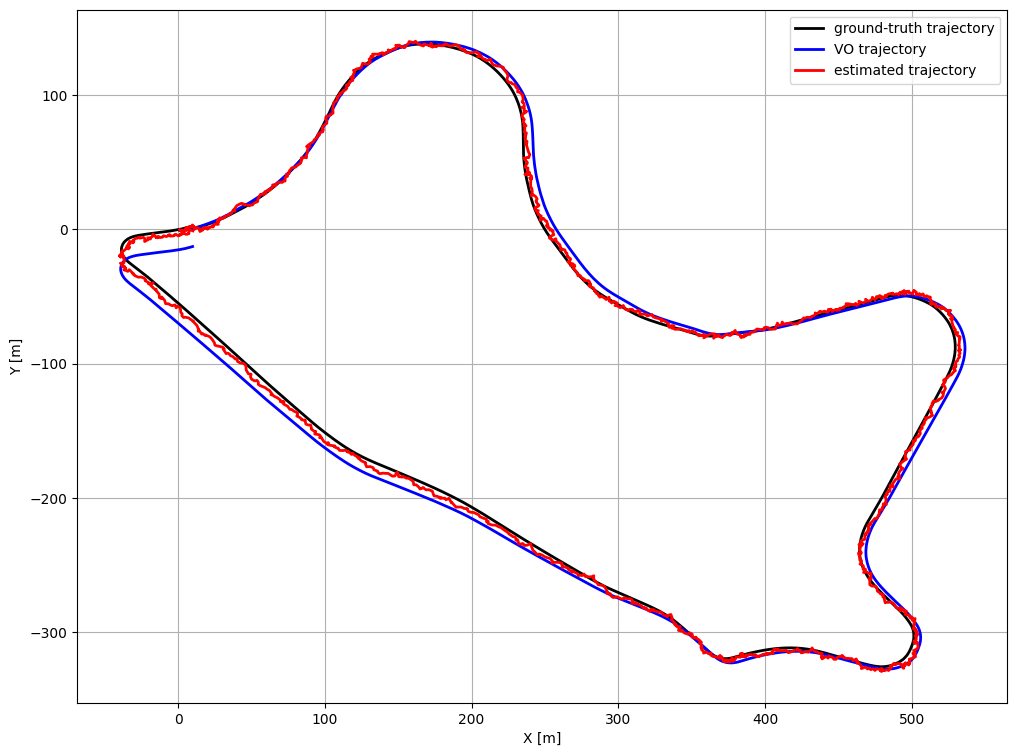

In [12]:

alpha_setup2_0 = 0.6
beta_setup2_0 = 2.
kappa_setup2_0 = 0.

ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2
)
error_ukf2_0 = ukf2_0.run(
    data=data,
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

## Setup2 Result

In [13]:
print(f"MAE: {error_ukf2_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ukf2_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ukf2_0[ErrorEnum.MAX]}")

mae_errors.append(error_ukf2_0[ErrorEnum.MAE])
rmse_errors.append(error_ukf2_0[ErrorEnum.RMSE])
max_errors.append(error_ukf2_0[ErrorEnum.MAX])

MAE: 1.949
RMSE: 2.422
MAX: 7.845


## Setup3 (INS input -> EKF with Visual Odometry and INS measurement)

In [14]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=SetupEnum.SETUP_3, 
  filter_type=FilterEnum.UKF, 
  noise_type=NoiseTypeEnum.CURRENT
)

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6878.12it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.549 m
Root Mean Squared Error: 2.098 m
Maximum Error: 6.744 m
-----------------------------------------------



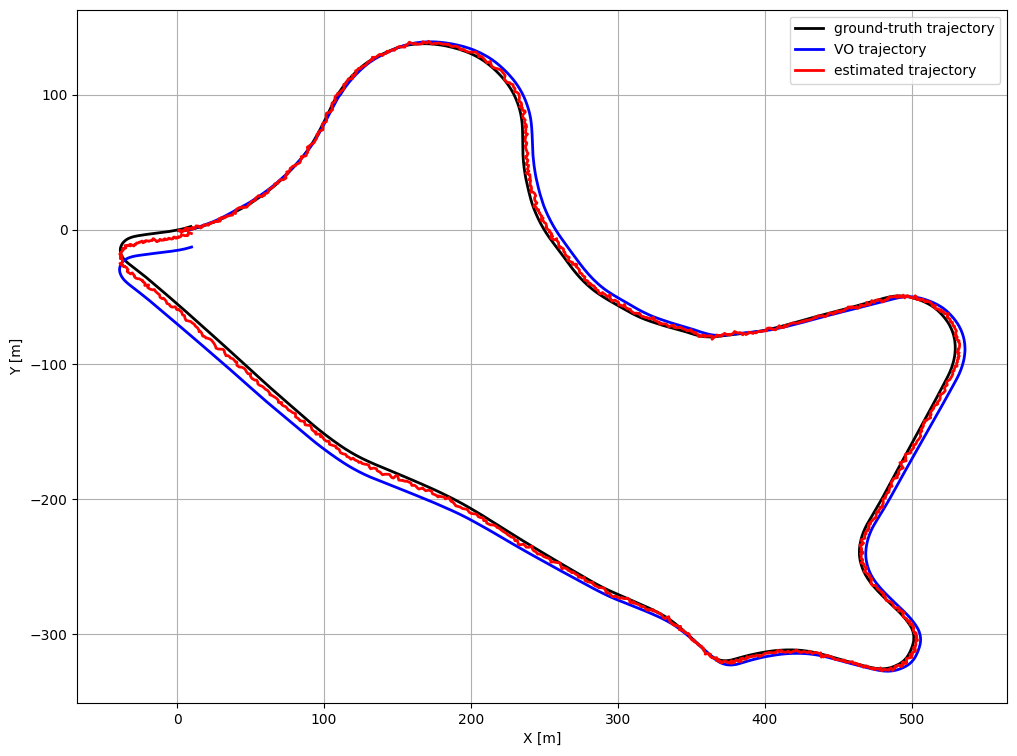

In [15]:
alpha_setup3_0 = 0.1
beta_setup3_0 = 2.
kappa_setup3_0 = 0.

ukf3_0 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3
)
error_ukf3_0 = ukf3_0.run(
    data=data, 
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

## Setup3 Result

In [16]:
print(f"MAE: {error_ukf3_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ukf3_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ukf3_0[ErrorEnum.MAX]}")

mae_errors.append(error_ukf3_0[ErrorEnum.MAE])
rmse_errors.append(error_ukf3_0[ErrorEnum.RMSE])
max_errors.append(error_ukf3_0[ErrorEnum.MAX])

MAE: 1.549
RMSE: 2.098
MAX: 6.744


# Result

In [17]:
errors = np.concatenate([mae_errors, rmse_errors, max_errors], axis=0).reshape(3, 4)
errors

array([[ 3.82 ,  4.17 ,  1.949,  1.549],
       [ 5.449,  5.682,  2.422,  2.098],
       [15.244, 16.566,  7.845,  6.744]])

In [18]:
error_labels = ["VO error", "UKF (IMU, VO)", 
                "UKF (IMU, VO + GPS)", "UKF (INS, VO + INS)"]
indices = ["MAE", "RMSE", "MAX"]
pd.DataFrame(errors, columns=error_labels, index=indices)

,VO error,"UKF (IMU, VO)","UKF (IMU, VO + GPS)","UKF (INS, VO + INS)"
MAE,3.820,4.170,1.949,1.549
RMSE,5.449,5.682,2.422,2.098
MAX,15.244,16.566,7.845,6.744
